In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv(r"C:\Users\louis\OneDrive - ECAM\ECAM\IA\labo\student_dataset\student_failure\train.csv")



print(df.shape)     # nombre de lignes / colonnes
print(df.columns)   # noms des colonnes
df.head()


(630000, 15)
Index(['id', 'age', 'genre', 'diplôme', 'heures_etude', 'assiduité_classe',
       'accès_internet', 'heures_sommeil', 'qualité_sommeil', 'méthode_etude',
       'évaluation_établissement', 'difficulté_examen', 'score_examen',
       'heures_fête', 'taille_etudiant'],
      dtype='object')


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


# nettoyage des données


In [ ]:
def categorize(score):
    if score < 50:
        return "fail"
    elif score <= 60:
        return "risk"
    else:
        return "pass"

df["target"] = df["score_examen"].apply(categorize)
df["target"].value_counts()

target
pass    358085
fail    161083
risk    110832
Name: count, dtype: int64

# EDA

In [ ]:
ids = df["id"]

df = df.drop(columns=["id"])
X = df.drop(columns=["score_examen", "target"])
y = df["target"]

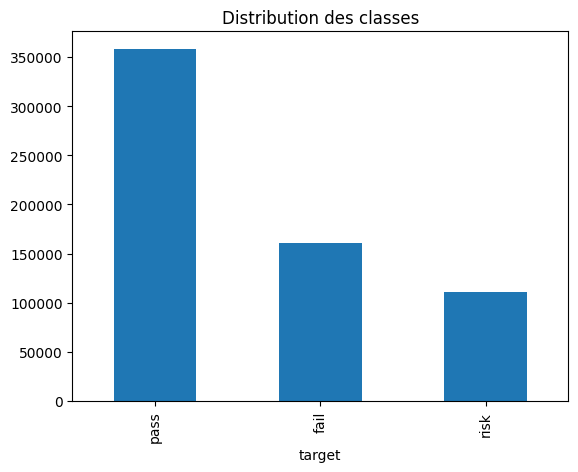

In [ ]:
#distribution des classes
df["target"].value_counts().plot(kind="bar")
plt.title("Distribution des classes")
plt.show()

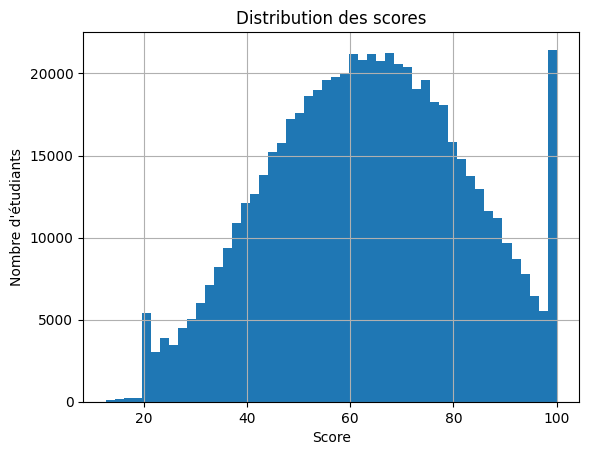

In [ ]:
#distribution des notes

df["score_examen"].hist(bins=50)
plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Nombre d'étudiants")
plt.show()

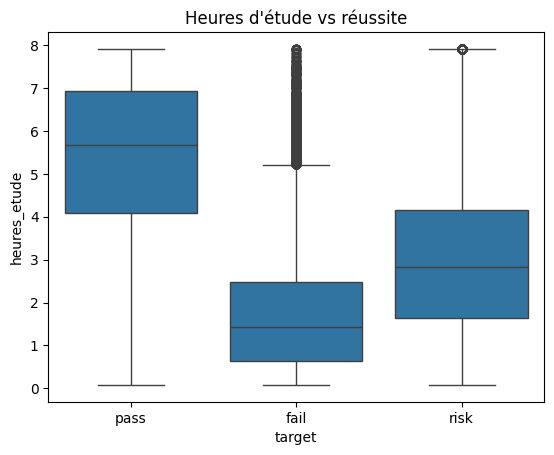

In [ ]:
import seaborn as sns

sns.boxplot(x="target", y="heures_etude", data=df)
plt.title("Heures d'étude vs réussite")
plt.show()

on peut voir que le nombre etude est fortement correllé a la reussite scolaire. Cependant on peut aussi observer que certains eleves ont très peu etudié voir pas et on quand meme reussi. Le nombre heure etude suel ne suffit pas a explqiuer la reussite

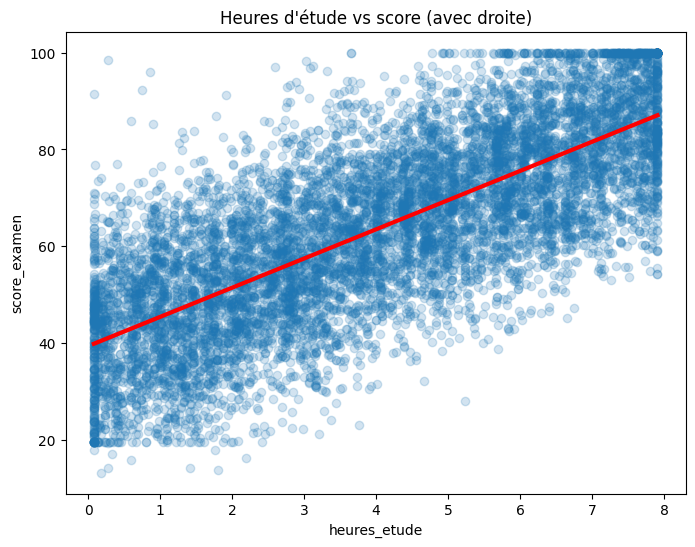

0.757647708785116


In [ ]:

sample = df.sample(10000)

plt.figure(figsize=(8,6))

sns.regplot(
    x="heures_etude",
    y="score_examen",
    data=sample,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red", "linewidth": 3}
)

plt.title("Heures d'étude vs score (avec droite)")
plt.show()

print(df["heures_etude"].corr(df["score_examen"]))

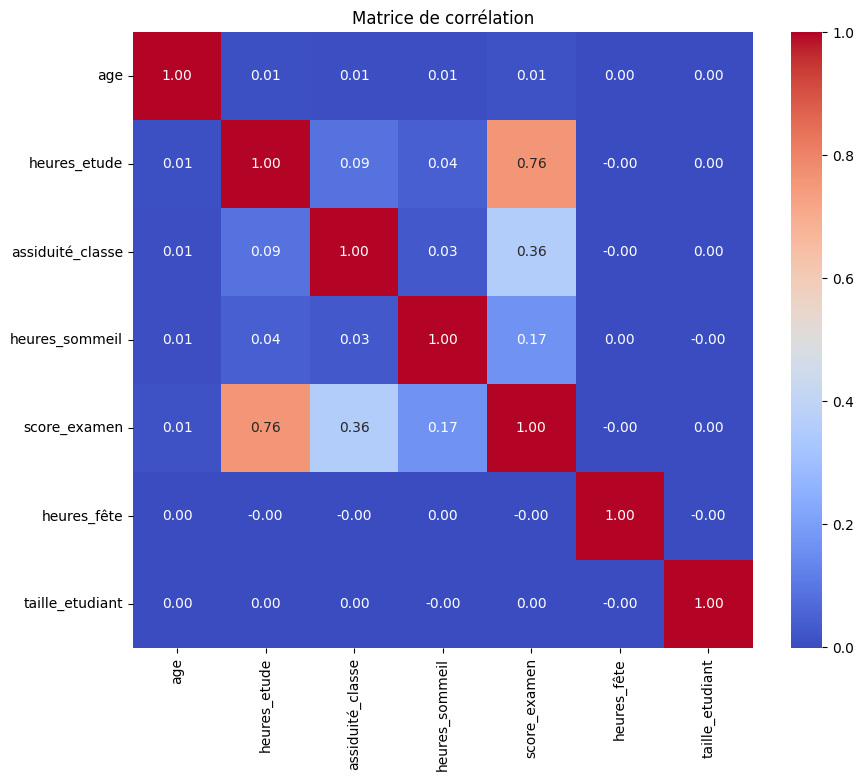

In [ ]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")